# Traffic Congestion Predictor

# Data Cleaning

This notebook cleans and prepares the Nigerian Transport and Logistics Traffic Flow dataset for machine learning.

Import Libraries

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

Load Dataset

In [52]:
df = pd.read_csv("../../dataset/processed/traffic_engineered.csv")

df.head()

,timestamp,segment_id,lat,lon,hour,avg_speed_kmh,density_veh_per_km,incidents,congestion_index,Congestion Level,date,month,day,day_of_week,is_weekend,is_peak_hour,time_of_day,congestion_category
0,2024-12-16 14:39:24,SEG-0162239,6.863982,13.298207,14,95.3,23.1,1,20.6,Low,2024-12-16,December,Monday,Monday,0,0,Afternoon,Low
1,2025-03-01 15:41:09,SEG-0117236,6.969183,14.701078,15,92.3,36.0,0,23.1,Low,2025-03-01,March,Saturday,Saturday,1,0,Afternoon,Low
2,2024-11-16 11:28:45,SEG-0024260,4.801158,2.687999,11,51.9,32.1,0,42.4,Moderate,2024-11-16,November,Saturday,Saturday,1,0,Morning,Moderate
3,2025-06-11 11:54:33,SEG-0093490,4.871314,8.517009,11,54.6,38.8,1,9.0,Low,2025-06-11,June,Wednesday,Wednesday,0,0,Morning,Low
4,2024-12-28 07:33:06,SEG-0162248,6.062270,10.121534,7,29.6,55.4,0,67.1,High,2024-12-28,December,Saturday,Saturday,1,1,Morning,High


Dataset Overview

In [53]:
print(df.shape)

df.info()

(180000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            180000 non-null  object 
 1   segment_id           180000 non-null  object 
 2   lat                  180000 non-null  float64
 3   lon                  180000 non-null  float64
 4   hour                 180000 non-null  int64  
 5   avg_speed_kmh        180000 non-null  float64
 6   density_veh_per_km   180000 non-null  float64
 7   incidents            180000 non-null  int64  
 8   congestion_index     180000 non-null  float64
 9   Congestion Level     180000 non-null  object 
 10  date                 180000 non-null  object 
 11  month                180000 non-null  object 
 12  day                  180000 non-null  object 
 13  day_of_week          180000 non-null  object 
 14  is_weekend           180000 non-null  int64  
 15  is_p

Check Missing Values

In [54]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
timestamp,0,0.0
segment_id,0,0.0
lat,0,0.0
lon,0,0.0
hour,0,0.0
avg_speed_kmh,0,0.0
density_veh_per_km,0,0.0
incidents,0,0.0
congestion_index,0,0.0
Congestion Level,0,0.0


Decision

Handle Missing Values
Numeric Columns

In [55]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

Categorical Columns

In [56]:
categorical_cols = df.select_dtypes(include="object").columns

df[categorical_cols] = df[categorical_cols].fillna(
    df[categorical_cols].mode().iloc[0]
)

Verify

In [57]:
df.isnull().sum()

timestamp              0
segment_id             0
lat                    0
lon                    0
hour                   0
avg_speed_kmh          0
density_veh_per_km     0
incidents              0
congestion_index       0
Congestion Level       0
date                   0
month                  0
day                    0
day_of_week            0
is_weekend             0
is_peak_hour           0
time_of_day            0
congestion_category    0
dtype: int64

Remove Duplicate Records

In [58]:
duplicates = df.duplicated().sum()

print(f"Duplicates: {duplicates}")

Duplicates: 0


Remove them

In [59]:
df = df.drop_duplicates()

Verify

In [60]:
df.duplicated().sum()

np.int64(0)

Verify Data Types

In [63]:
df.dtypes

timestamp              datetime64[ns]
segment_id                     object
lat                           float64
lon                           float64
hour                            int64
avg_speed_kmh                 float64
density_veh_per_km            float64
incidents                       int64
congestion_index              float64
Congestion Level               object
date                           object
month                          object
day                            object
day_of_week                    object
is_weekend                      int64
is_peak_hour                    int64
time_of_day                    object
congestion_category            object
dtype: object

Hour Still Object

In [62]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

Remove Impossible Values

Traffic datasets often contain impossible values.

In [66]:
df["avg_speed_kmh"].describe()

count    180000.000000
mean         55.827961
std          21.218505
min           5.000000
25%          40.200000
50%          54.800000
75%          70.600000
max         120.000000
Name: avg_speed_kmh, dtype: float64

Check density

In [68]:
df = df[
    df["density_veh_per_km"] >= 0
]

Outlier Detection

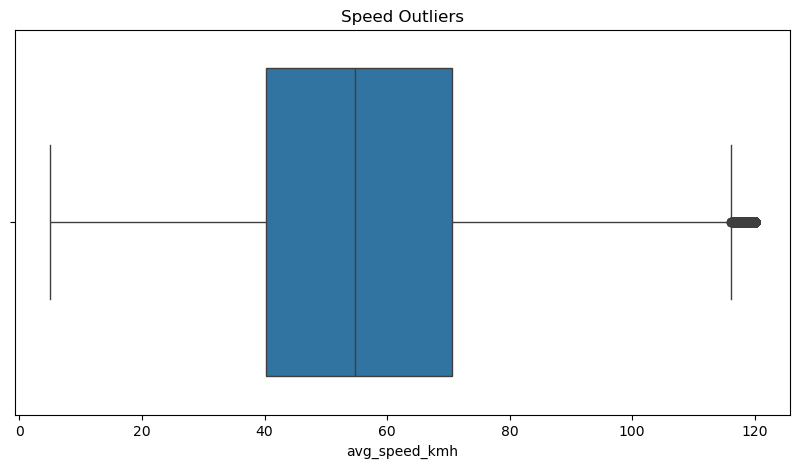

In [69]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["avg_speed_kmh"]
)

plt.title("Speed Outliers")

plt.show()

IQR Method

In [71]:
Q1 = df["avg_speed_kmh"].quantile(0.25)

Q3 = df["avg_speed_kmh"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

df = df[
    (df["avg_speed_kmh"] >= lower)
    &
    (df["avg_speed_kmh"] <= upper)
]

Check Class Balance

In [72]:
df["congestion_category"].value_counts()

congestion_category
Moderate    95885
Low         40628
High        39718
Severe       3418
Name: count, dtype: int64

Verify Engineered Features

In [73]:
features = [
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "time_of_day"
]

df[features].head()

,day_of_week,is_weekend,is_peak_hour,time_of_day
0,Monday,0,0,Afternoon
1,Saturday,1,0,Afternoon
2,Saturday,1,0,Morning
3,Wednesday,0,0,Morning
4,Saturday,1,1,Morning


to keep the timestamp column

In [77]:
df_model = df.copy()

Make Sure Timestamp Is Properly Formatted

In [78]:
df_model["timestamp"] = pd.to_datetime(
    df_model["timestamp"],
    errors="coerce"
)

Check

In [79]:
print(df_model["timestamp"].dtype)

datetime64[ns]


Check for Invalid Timestamps

In [80]:
invalid_timestamps = df_model["timestamp"].isna().sum()

print(
    f"Invalid timestamps: {invalid_timestamps}"
)

Invalid timestamps: 0


Final Dataset Check

In [81]:
print(df_model.shape)

df_model.head()

(179649, 18)


,timestamp,segment_id,lat,lon,hour,avg_speed_kmh,density_veh_per_km,incidents,congestion_index,Congestion Level,date,month,day,day_of_week,is_weekend,is_peak_hour,time_of_day,congestion_category
0,2024-12-16 14:39:24,SEG-0162239,6.863982,13.298207,14,95.3,23.1,1,20.6,Low,2024-12-16,December,Monday,Monday,0,0,Afternoon,Low
1,2025-03-01 15:41:09,SEG-0117236,6.969183,14.701078,15,92.3,36.0,0,23.1,Low,2025-03-01,March,Saturday,Saturday,1,0,Afternoon,Low
2,2024-11-16 11:28:45,SEG-0024260,4.801158,2.687999,11,51.9,32.1,0,42.4,Moderate,2024-11-16,November,Saturday,Saturday,1,0,Morning,Moderate
3,2025-06-11 11:54:33,SEG-0093490,4.871314,8.517009,11,54.6,38.8,1,9.0,Low,2025-06-11,June,Wednesday,Wednesday,0,0,Morning,Low
4,2024-12-28 07:33:06,SEG-0162248,6.062270,10.121534,7,29.6,55.4,0,67.1,High,2024-12-28,December,Saturday,Saturday,1,1,Morning,High


Save Clean Dataset

In [82]:
OUTPUT_PATH = "../../dataset/processed/traffic_cleaned.csv"

df_model.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


Traffic Density

In [83]:
traffic[
    traffic["density_veh_per_km"] < 0
]

,timestamp,segment_id,lat,lon,hour,avg_speed_kmh,density_veh_per_km,incidents,congestion_index,year,month,day,day_of_week
